Unnamed: 0 y Vict Age
R2: -2.8722971429751e-05
Date Occ y Vict Age
R2: 0.7587581006179509
Time Occ y Vict Age
R2: 0.0037598541209281633
Area Name y Vict Age
R2: -0.049814408278929356
Crime Desc y Vict Age
R2: -0.0006415156541483835
Vict Sex y Vict Age
R2: 0.30539758528697636
Vict Descent y Vict Age
R2: -0.058447879632305355


/run/media/system/D2/Programacion/Mineria/ClaseMineriaDatos/.venv/lib64/python3.12/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 3 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


Premis Desc y Vict Age
R2: 0.01437845911907365
Weapon y Vict Age
R2: 0.03719146265097062
Crm Status y Vict Age
R2: -0.32456687683616137


/run/media/system/D2/Programacion/Mineria/ClaseMineriaDatos/.venv/lib64/python3.12/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


LAT y Vict Age
R2: -0.00024067698277963068
LON y Vict Age
R2: 0.016957053838197234
Unnamed: 0 y LAT
R2: -2.4170908129672597e-05
Date Occ y LAT
R2: 0.7597333669781405
Time Occ y LAT
R2: 0.004254756768194534
Area Name y LAT
R2: -0.05127648255175066
Crime Desc y LAT
R2: -0.0018099060293970126
Vict Age y LAT
R2: 0.14250558759504972
Vict Sex y LAT
R2: 0.3615607824711482
Vict Descent y LAT
R2: -0.057703419883941454


/run/media/system/D2/Programacion/Mineria/ClaseMineriaDatos/.venv/lib64/python3.12/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 3 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


Premis Desc y LAT
R2: 0.014360510111965374
Weapon y LAT
R2: 0.037881054441387785


KeyboardInterrupt: 

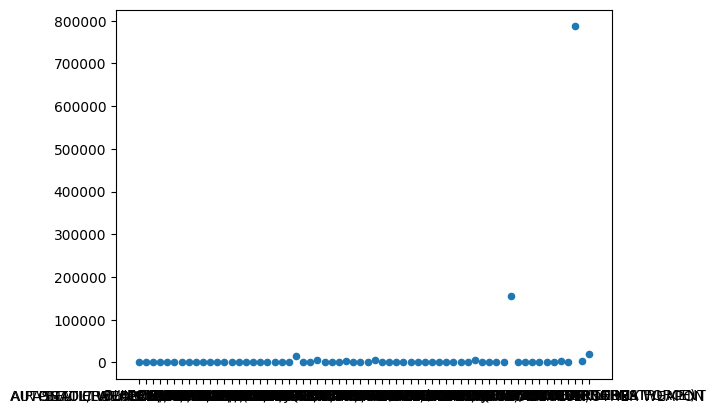

In [23]:
#Iniciamos practica 8import pandas as pd
import pandas as pd
from tabulate import tabulate
import os
import statsmodels.api as sm
import numbers
import matplotlib.pyplot as plt
from io import StringIO

ruta = "img/practica9"

def transform_variable(df: pd.DataFrame, x: str) -> pd.Series:
    if isinstance(df[x][0], numbers.Number):
        return df[x]
    else:
        return pd.Series([i for i in range(0, len(df[x]))])

def linear_regression(df: pd.DataFrame, x: str, y: str) -> None:
    fixed_x = transform_variable(df, x)
    model = sm.OLS(df[y], sm.add_constant(fixed_x)).fit()
    print(f"R2: {model.rsquared_adj}")

    coef = pd.read_html(StringIO(model.summary().tables[1].as_html()), header=0, index_col=0)[0]['coef']
    df.plot(x=x, y=y, kind='scatter')
    plt.plot(df[x], [coef.values[1] * x + coef.values[0] for _, x in fixed_x.items()], color='red')
    plt.xticks(rotation=90)
    plt.savefig(f'img/lr_{y}_{x}.png')
    plt.close()

df = pd.read_csv("../csv/registroCrimenes.csv", index_col=False)
#regresamos tiempo a entero
df['Time Occ'] = df['Time Occ'].str.replace(':', '').astype(int)
os.makedirs(ruta, exist_ok=True)

columnas_numericas = [ 'Vict Age', 'LAT', 'LON']
columnas_categoricas = ["Date Occ", "Time Occ", 'Weapon', 'Area Name', 'Crime Desc', 'Vict Sex', 'Vict Descent', 'Premis Desc', 'Crm Status']

print(f'Graficas generadas en: {ruta}')
for cn in columnas_numericas:
    for col in df.columns:
        if col == cn:
            continue
        print(f'{col} y {cn}')
        df_agg = df.groupby([col])[[cn]].agg({cn: ['sum']})
        df_agg.reset_index(inplace=True)

        df_agg.columns = [col,f"{cn} suma"]
        df_agg.reset_index(inplace=True)
        #print(tabulate(df_agg, headers='keys', tablefmt='pretty'))
        linear_regression(df_agg, col, f"{cn} suma")

In [5]:
import pandas as pd
df = pd.read_csv("../csv/registroCrimenes.csv", index_col=False)
df.drop(columns=["Unnamed: 0", "Unnamed: 0.1", "Unnamed: 0.2"], inplace=True)

df.to_csv("../csv/registroCrimenes.csv", index = False)


In [ ]:
#Inicia practica 10
import pandas as pd
from tabulate import tabulate
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mode
import matplotlib

def get_cmap(n, name="hsv"):
    return matplotlib.colormaps.get_cmap(name)

def scatter_group_by(file_path, df, x_column, y_column, label_column):
    fig, ax = plt.subplots()
    labels = pd.unique(df[label_column])
    cmap = get_cmap(len(labels) + 1)
    for i, label in enumerate(labels):
        filter_df = df.query(f"{label_column} == '{label}'")
        ax.scatter(filter_df[x_column], filter_df[y_column], label=label, color=cmap(i))
    ax.legend()
    plt.savefig(file_path)
    plt.close()

def euclidean_distance(p_1: np.array, p_2: np.array) -> float:
    return np.sqrt(np.sum((p_2 - p_1) ** 2))

def k_nearest_neightbors(points, labels, input_data, k):
    label_indices = {label: index for index, label in enumerate(pd.unique(labels))}
    indices_labels = {index: label for label, index in label_indices.items()}
    input_distances = [
        [euclidean_distance(input_point, point) for point in points]
        for input_point in input_data
    ]
    points_k_nearest = [
        np.argsort(input_point_dist)[:k] for input_point_dist in input_distances
    ]
    return [
        indices_labels[mode([label_indices[labels[index]] for index in point_nearest]).mode]
        for point_nearest in points_k_nearest
    ]

df = pd.read_csv("../csv/registroCrimenes.csv", index_col=False)
df = df.rename(columns={
    "Date Occ": "Date_Occ",
    "Vict Age": "Vict_Age",
    "Time Occ": "Time_Occ",
    "Vict Sex": "Vict_Sex",
    "Crime Desc": "Crime_Desc",
    'Vict Descent': 'Vict_Descent',
    'Area Name': 'Area_Name',
    'Premis Desc':'Premis_Desc',
    'Crm Status': 'Crm_Status'})
scatter_group_by("img/practica10/groups.png", df, "LAT", "LON", "Area_Name")


list_t = [
    (np.array([row['LAT'], row['LON']]), row['Area_Name'])
    for _, row in df.iterrows()
]
input_data = [point for point, _ in list_t]
labels = np.array([label for _, label in list_t])

# Punto nuevo a clasificar
new_points = [np.array([34.05, -118.24])]
kn = k_nearest_neightbors(input_data, labels, new_points, 5)
print(kn)

[np.str_('Central')]


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

df = pd.read_csv("../csv/registroCrimenes.csv", index_col=False)
df = df.rename(columns={
    "Date Occ": "Date_Occ",
    "Vict Age": "Vict_Age",
    "Time Occ": "Time_Occ",
    "Vict Sex": "Vict_Sex",
    "Crime Desc": "Crime_Desc",
    'Vict Descent': 'Vict_Descent',
    'Area Name': 'Area_Name',
    'Premis Desc':'Premis_Desc',
    'Crm Status': 'Crm_Status'})

ruta = 'img/Practica12'

os.makedirs(ruta, exist_ok=True)

df_sample = df.sample(n=500, random_state=42)  # muestra para performance

def get_cmap(n, name="hsv"):
    return plt.colormaps.get_cmap(name)

def euclidean_distance(p_1, p_2):
    return np.sqrt(np.sum((p_2 - p_1) ** 2))

def scatter_group_by(file_path, df, x_column, y_column, label_column):
    fig, ax = plt.subplots()
    labels = pd.unique(df[label_column])
    cmap = get_cmap(len(labels) + 1)
    for i, label in enumerate(labels):
        filter_df = df.query(f"{label_column} == '{label}'")
        ax.scatter(filter_df[x_column], filter_df[y_column], label=label)
    ax.legend()
    plt.set_cmap(cmap)
    plt.savefig(file_path)
    plt.close()

def calculate_means(points, labels, clusters):
    mean = []
    for k in range(clusters):
        m = np.mean(points[labels == k], axis=0)
        mean.append(m)
    return mean

def calculate_nearest_k(point, actual_means):
    distance = [euclidean_distance(mean, point) for mean in actual_means]
    return (point, np.argmin(distance))

def k_means(points, k):
    N = len(points)
    x = np.array(points)
    y = np.random.randint(0, k, N)
    dimensions = len(points[0])
    mean = np.zeros((k, dimensions)) 

    for t in range(15):
        actual_mean = calculate_means(points=x, labels=y, clusters=k)
        y = np.array([calculate_nearest_k(point=point, actual_means=actual_mean)[1] for point in x])

        df_points = pd.DataFrame(x, columns=['x', 'y'])
        df_points['label'] = np.char.mod('%d', y)
        df_mean = pd.DataFrame(actual_mean, columns=['x', 'y'])
        df_mean['label'] = ['centroid' for _ in range(len(actual_mean))]
        df_plot = pd.concat([df_points, df_mean])
        scatter_group_by(f"{ruta}/kmeans_{t}.png", df_plot, "x", "y", "label")

        if np.array_equal(np.array(actual_mean), mean):
            break
        mean = np.array(actual_mean).copy()
    return mean

list_t = [
    (np.array([row['LAT'], row['LON']]), row['Area_Name'])
    for _, row in df_sample.iterrows()
]
points = [point for point, _ in list_t]

kn = k_means(points, 5)
print(f"Centroides finales: {kn}")

Centroides finales: [[  34.20647159 -118.41290682]
 [  34.01888586 -118.39106768]
 [  34.0449188  -118.27873077]
 [  33.79611364 -118.29025455]
 [  34.19923684 -118.56428421]]
